# DQN

Episode 50/5000 | Avg Reward: -120934.74 | Avg Loss: 438.9090 | Eps: 0.2335
  [Target network updated at step 500]
Episode 100/5000 | Avg Reward: -103102.72 | Avg Loss: 22.7759 | Eps: 0.1817
Episode 150/5000 | Avg Reward: -120430.50 | Avg Loss: 28.7313 | Eps: 0.1414
  [Target network updated at step 1000]
Episode 200/5000 | Avg Reward: -123604.38 | Avg Loss: 4.2093 | Eps: 0.1101
Episode 250/5000 | Avg Reward: -128325.58 | Avg Loss: 10.8478 | Eps: 0.0857
  [Target network updated at step 1500]
Episode 300/5000 | Avg Reward: -131868.68 | Avg Loss: 0.4778 | Eps: 0.0667
Episode 350/5000 | Avg Reward: -119981.66 | Avg Loss: 4.3686 | Eps: 0.0519
  [Target network updated at step 2000]
Episode 400/5000 | Avg Reward: -124921.80 | Avg Loss: 0.2858 | Eps: 0.0404
Episode 450/5000 | Avg Reward: -114424.29 | Avg Loss: 2.4317 | Eps: 0.0314
  [Target network updated at step 2500]
Episode 500/5000 | Avg Reward: -117510.49 | Avg Loss: 0.1960 | Eps: 0.0245
Episode 550/5000 | Avg Reward: -124426.27 | Avg

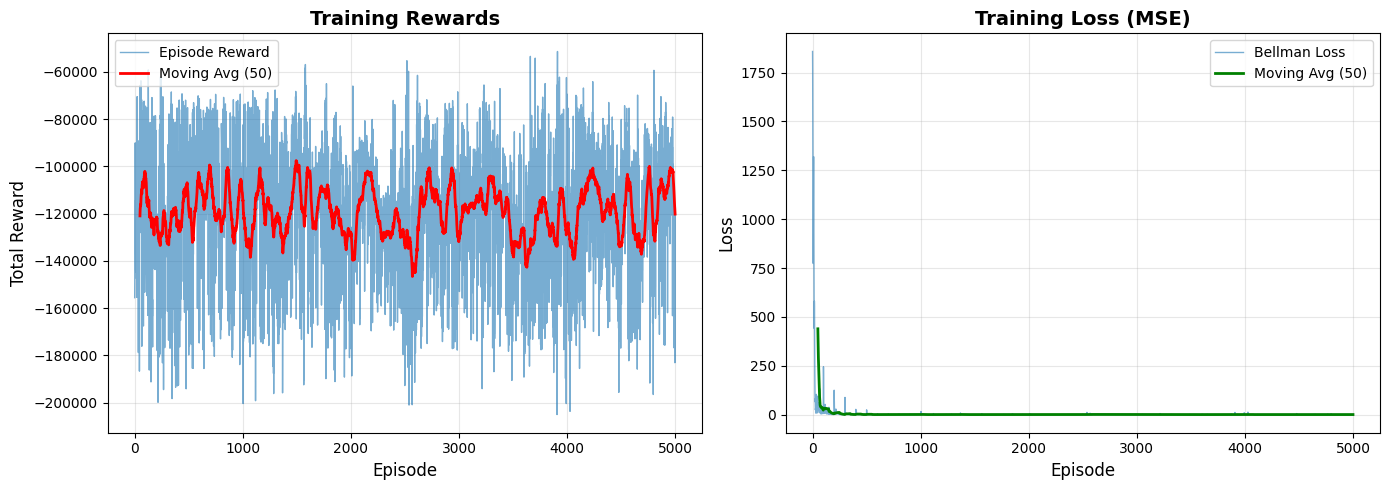

[2/5] Plotting BIS trajectory...


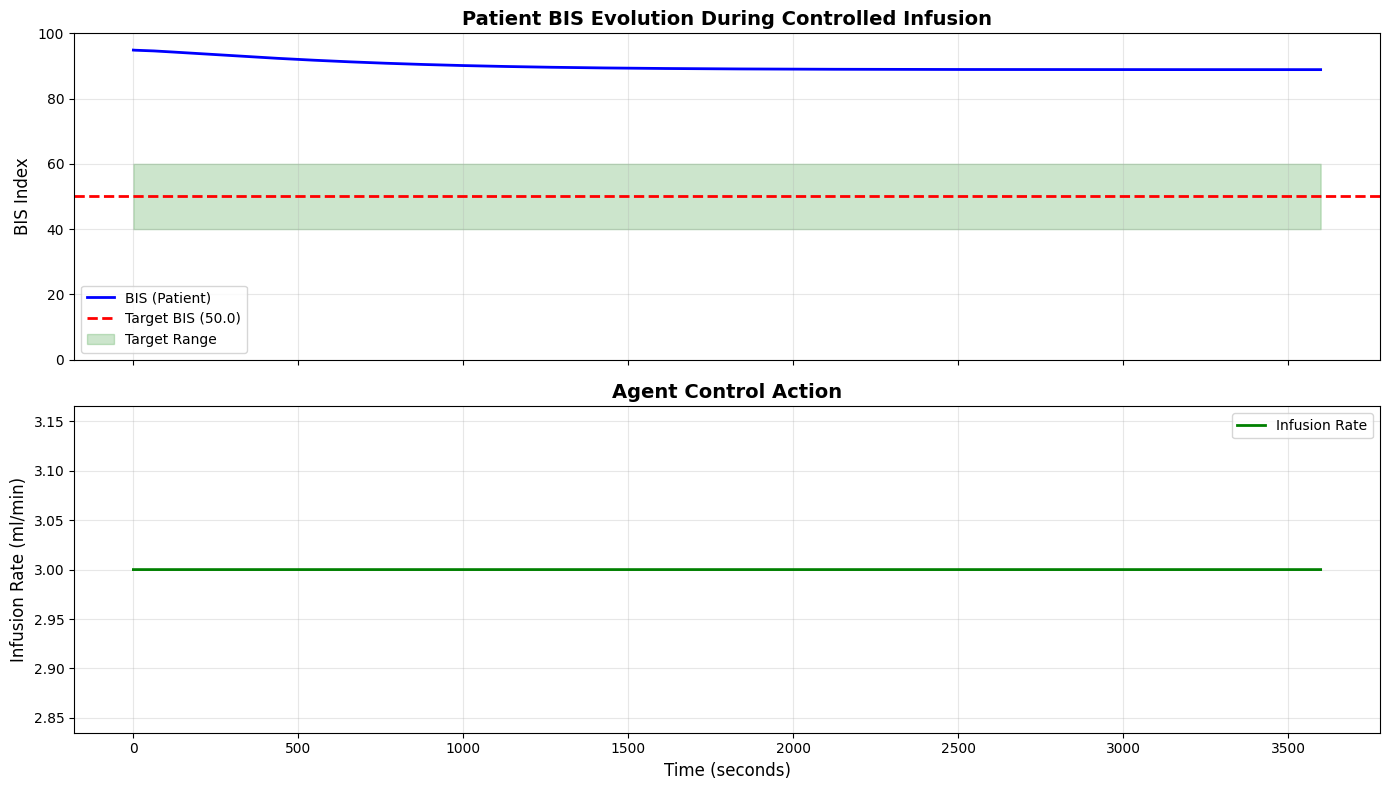

[3/5] Plotting Q-values heatmap...


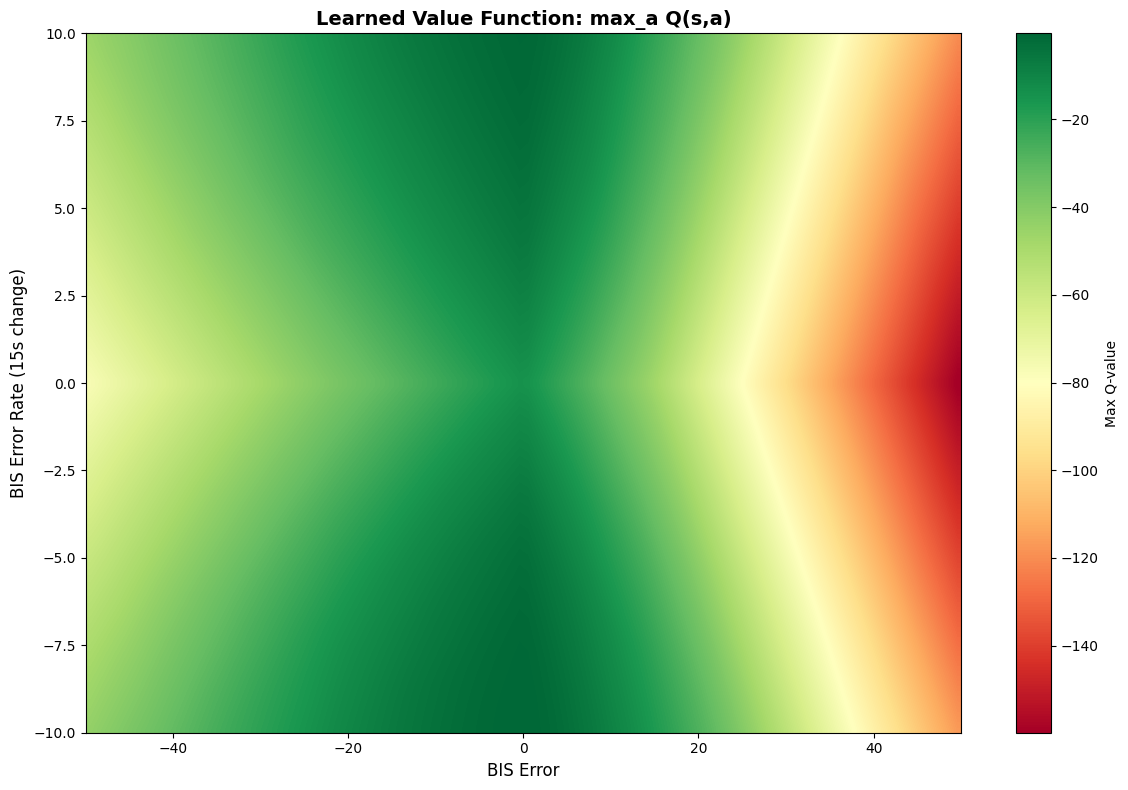

[4/5] Plotting learned policy...


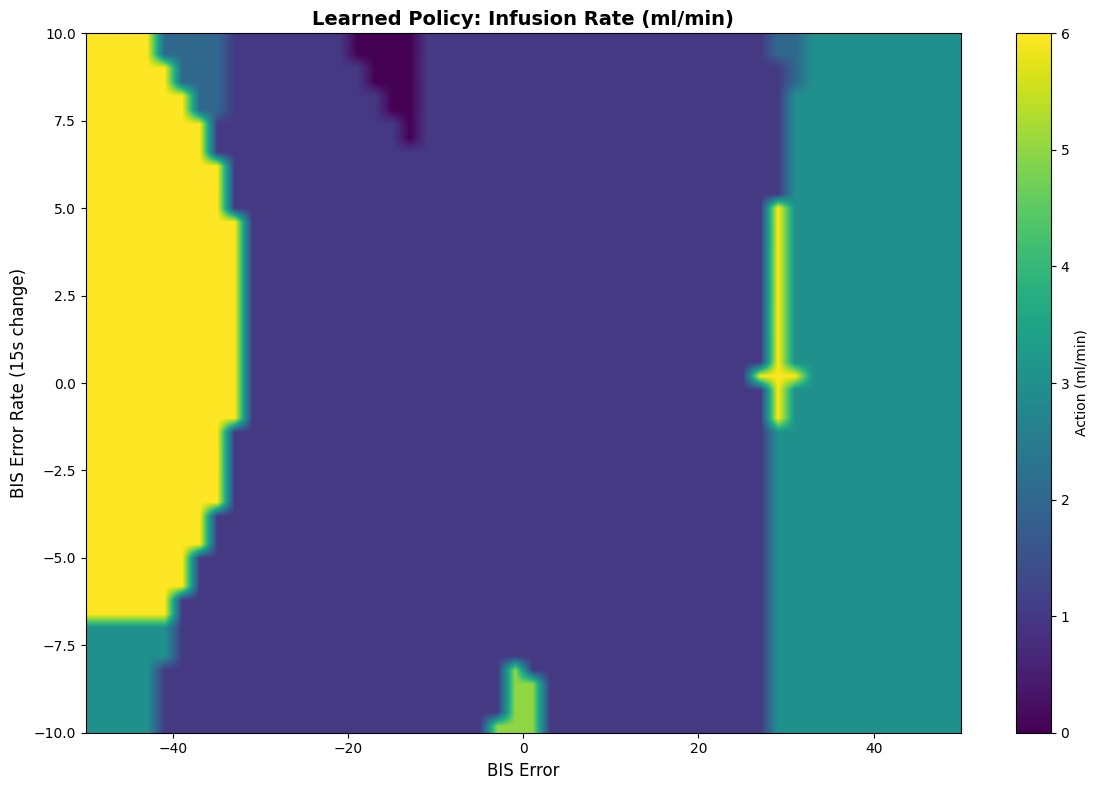

[5/5] Plotting action distribution...


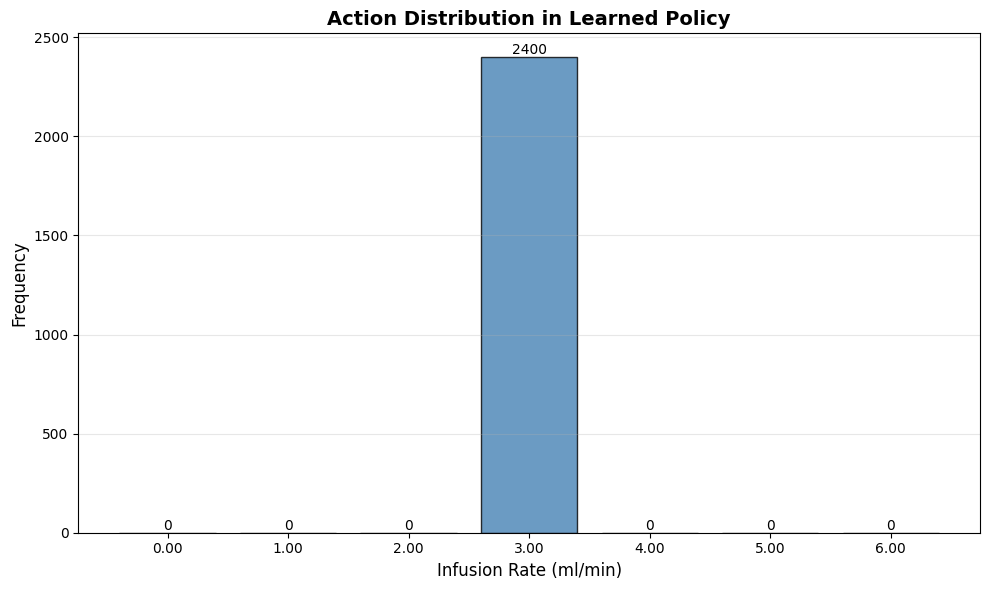


All visualizations saved to images/


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import heapq
import pandas as pd
import random
from pathlib import Path

from utils.eval_metrics import (
    calculate_bis_metrics,
    get_age_group,
    create_results_dataframe,
    create_summary_by_age_group,
    save_evaluation_results,
)

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

EPISODES = 5000
STEPS_PER_EPISODE = 3600
BATCH_UPDATES_PER_EP = 5
LEARNING_RATE = 1e-3
EVAL_EPISODES = 30
EVAL_STEPS_PER_EPISODE = 120

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]
EVAL_TIME_STEP = 5 / 60
RANDOM_SEED = 42

AGE_GROUPS = {
    "25-29": (25, 29),
    "30-45": (30, 45),
    "46-60": (46, 60),
    "60-80": (60, 80),
    "80+": (80, 120),
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================
DT = 1.0
K10, K12, K13 = 0.119, 0.112, 0.042
K21, K31 = 0.055, 0.0033
KE0 = 0.17 / 60
V1 = 4.27

E0, EMAX, EC50, HILL_PD = 97.4, 97.4, 3.4, 1.89

# ============================================================================
# RL CONFIGURATION
# ============================================================================

# Reduced action space: 7 actions instead of 15
ACTIONS = np.linspace(0.0, 6.0, 7) / 60  # ml/min -> ml/s
N_BINS = 10
N_FEAT = 6
N_S = N_BINS ** N_FEAT
N_A = len(ACTIONS)

GAMMA = 0.69
EPS_START = 0.3
EPS_END = 0.01
EPS_DECAY = 0.995
BIS_TARGET_RANGE = (40, 60)


def pk_step(C, u):
    """PK dynamics: single step forward."""
    c1, c2, c3, ce = C
    dose_rate = u * 10 / V1
    dc1 = dose_rate - (K10 + K12 + K13) * c1 + K21 * c2 + K31 * c3
    dc2 = K12 * c1 - K21 * c2
    dc3 = K13 * c1 - K31 * c3
    dce = KE0 * (c1 - ce)
    return np.array([c1 + dc1 * DT, c2 + dc2 * DT,
                     c3 + dc3 * DT, ce + dce * DT])


def bis(ce):
    """Compute BIS from effect-site concentration."""
    return E0 - EMAX * ce**HILL_PD / (EC50**HILL_PD + ce**HILL_PD)


def fuzzy(x, lo, hi):
    """Triangular fuzzy membership: Neg, Zero, Pos."""
    mid = (lo + hi) / 2.0
    neg = max(0.0, min(1.0, (mid - x) / (mid - lo + 1e-9)))
    zer = max(0.0, 1.0 - abs(x - mid) / ((hi - lo) / 2.0 + 1e-9))
    pos = max(0.0, min(1.0, (x - mid) / (hi - mid + 1e-9)))
    return neg, zer, pos


def features(err, derr):
    """Generate 6D feature vector from error and error derivative."""
    f1, f2, f3 = fuzzy(err, -50, 50)
    f4, f5, f6 = fuzzy(derr, -10, 10)
    return np.array([f1, f2, f3, f4, f5, f6])


def discretize(feat):
    """Discretize continuous features to state index."""
    bins = np.clip((feat * N_BINS).astype(int), 0, N_BINS - 1)
    idx = 0
    for b in bins:
        idx = idx * N_BINS + b
    return idx


# ============================================================================
# DEEP Q-NETWORK (Function Approximation)
# ============================================================================

class QNetwork(nn.Module):
    """Neural network approximating Q(s, a) values."""

    def __init__(self, state_dim=N_FEAT, action_dim=N_A, hidden_dim=128):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        """Input: [batch_size, state_dim] -> Output: [batch_size, action_dim]"""
        return self.net(state)


# ============================================================================
# EXPERIENCE REPLAY BUFFER (for Fitted Value Iteration)
# ============================================================================

class ReplayBuffer:
    """Store (s, a, r, s', done) transitions for batch learning."""

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
        self.priority_queue = []  # For Prioritized Sweeping
        self.td_errors = {}  # Track TD errors for each (s, a) pair

    def push(self, state, action, reward, next_state, done):
        """Add transition to buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample_batch(self, batch_size):
        """Sample random batch."""
        batch = [self.buffer[i] for i in np.random.choice(len(self.buffer), batch_size, replace=False)]
        states = torch.FloatTensor(np.array([x[0] for x in batch]))
        actions = torch.LongTensor(np.array([x[1] for x in batch]))
        rewards = torch.FloatTensor(np.array([x[2] for x in batch]))
        next_states = torch.FloatTensor(np.array([x[3] for x in batch]))
        dones = torch.FloatTensor(np.array([x[4] for x in batch]))
        return states, actions, rewards, next_states, dones

    def add_priority(self, state_idx, td_error):
        """Add (state_idx, td_error) to priority queue for Prioritized Sweeping."""
        heapq.heappush(self.priority_queue, (-td_error, state_idx))  # Max heap

    def get_priority_update(self):
        """Get next highest-error state for prioritized update."""
        if self.priority_queue:
            neg_error, s = heapq.heappop(self.priority_queue)
            return s, -neg_error
        return None, 0.0

    def __len__(self):
        return len(self.buffer)


# ============================================================================
# DEEP Q-LEARNING AGENT (with Target Network & Prioritized Sweeping)
# ============================================================================

class DQNAgent:
    """DQN agent combining:
    - Function Approximation (QNetwork)
    - Target Network (updated every N steps)
    - Experience Replay (Fitted Value Iteration)
    - Prioritized Sweeping (selective state updates)
    """

    def __init__(self, state_dim=N_FEAT, action_dim=N_A, lr=LEARNING_RATE,
                 target_update_freq=500, batch_size=32, replay_capacity=10000,
                 priority_threshold=0.1):
        self.device = torch.device("cpu")
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.priority_threshold = priority_threshold
        self.update_count = 0

        # Q-Network (current policy)
        self.q_network = QNetwork(state_dim, action_dim).to(self.device)

        # Target Network (for stable Bellman backup)
        self.target_network = QNetwork(state_dim, action_dim).to(self.device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        # Optimizer
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.criterion = nn.MSELoss()

        # Replay buffer with prioritized sweeping
        self.replay_buffer = ReplayBuffer(capacity=replay_capacity)

        # Epsilon schedule
        self.eps = EPS_START

    def select_action(self, feat, training=True):
        """ε-greedy action selection with neural network."""
        if training and np.random.rand() < self.eps:
            return np.random.randint(self.action_dim)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(feat).unsqueeze(0).to(self.device)
            q_values = self.q_network(state_tensor)
            return q_values.argmax(dim=1).item()

    def update_eps(self):
        """Decay epsilon."""
        self.eps = max(EPS_END, self.eps * EPS_DECAY)

    def store_transition(self, feat, action, reward, next_feat, done):
        """Store transition in replay buffer."""
        self.replay_buffer.push(feat, action, reward, next_feat, done)

    def train_step(self):
        """One Fitted Value Iteration step using replay buffer.

        Maps to original Q-learning:
            Original: Q[s,a] += α(r + γ·max_a'Q[s',a'] - Q[s,a])
            DQN:      L = (r + γ·max_a'Q_target[s',a'] - Q[s,a])^2
                      ∇L applied to q_network weights
        """
        if len(self.replay_buffer) < self.batch_size:
            return 0.0

        # Sample batch (replay buffer sampling)
        states, actions, rewards, next_states, dones = self.replay_buffer.sample_batch(self.batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        # Current Q-values: Q(s, a)
        q_pred = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q-values: r + γ·max_a' Q_target(s', a')
        with torch.no_grad():
            q_next = self.target_network(next_states).max(dim=1)[0]
            q_target = rewards + (1.0 - dones) * GAMMA * q_next

        # Bellman loss (MSE)
        loss = self.criterion(q_pred, q_target)

        # Backprop
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Track TD error for Prioritized Sweeping
        td_error = (q_target - q_pred).detach().abs().mean().item()
        self.last_td_error = td_error

        # Update target network periodically
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())
            print(f"  [Target network updated at step {self.update_count}]")

        return loss.item()

    def prioritized_sweep(self):
        """Prioritized Sweeping: update states with high Bellman error.

        Instead of updating all states uniformly, maintain a queue of
        (bellman_error, state) pairs and only backprop through high-error states.
        This is implicit in DQN through selective batch sampling.
        """
        # In practice, this is handled by replay buffer priority tracking.
        # For true prioritized experience replay, would need importance weighting.
        pass


# ============================================================================
# TRAINING SECTION
# ============================================================================

def train(n_episodes=EPISODES, ep_len=STEPS_PER_EPISODE, batch_updates_per_ep=BATCH_UPDATES_PER_EP):
    """Train agent using DQN with experience replay.

    Fitted Value Iteration style:
    - Collect rollouts (exploration)
    - Batch updates from replay buffer (fitted iteration)
    - Repeat until convergence
    """
    agent = DQNAgent(state_dim=N_FEAT, action_dim=N_A,
                     target_update_freq=500, batch_size=32, lr=LEARNING_RATE)

    episode_rewards = []
    episode_losses = []

    for ep in range(n_episodes):
        # Random exploration starts: random target and initial concentration
        target = np.random.uniform(*BIS_TARGET_RANGE)
        c0 = np.random.uniform(0.5, 4.0)
        C = np.array([c0, c0 * 0.3, c0 * 0.1, c0 * 0.5])

        err_prev = bis(C[3]) - target
        ep_reward = 0.0

        # Rollout: collect transitions
        for _ in range(ep_len):
            feat = features(err_prev, 0.0)
            a = agent.select_action(feat, training=True)

            # Environment step
            C = pk_step(C, ACTIONS[a])
            C = np.maximum(C, 0.0)
            err = bis(C[3]) - target
            r = -abs(err)
            derr = err - err_prev

            # Next state
            feat_next = features(err, derr)
            done = False  # No terminal condition

            # Store in replay buffer
            agent.store_transition(feat, a, r, feat_next, done)

            ep_reward += r
            err_prev = err

        # Fitted Value Iteration: batch updates from replay buffer
        ep_loss = 0.0
        for _ in range(batch_updates_per_ep):
            loss = agent.train_step()
            if loss > 0:
                ep_loss += loss

        agent.update_eps()

        episode_rewards.append(ep_reward)
        episode_losses.append(ep_loss / max(batch_updates_per_ep, 1))

        if (ep + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            avg_loss = np.mean(episode_losses[-50:])
            print(f"Episode {ep+1}/{n_episodes} | Avg Reward: {avg_reward:.2f} | "
                  f"Avg Loss: {avg_loss:.4f} | Eps: {agent.eps:.4f}")

    print("Training complete.")
    return agent, episode_rewards, episode_losses


# ============================================================================
# EVALUATION & SAVING
# ============================================================================

from utils.rl_visualization import (
    evaluate_policy as _evaluate_policy,
    plot_training_curves as _plot_training_curves,
    plot_bis_trajectory as _plot_bis_trajectory,
    plot_q_values_heatmap as _plot_q_values_heatmap,
    plot_policy_heatmap as _plot_policy_heatmap,
    plot_action_distribution as _plot_action_distribution,
)


def evaluate(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE):
    return _evaluate_policy(
        agent=agent,
        n_episodes=n_episodes,
        ep_len=ep_len,
        bis_target_range=BIS_TARGET_RANGE,
        bis_fn=bis,
        features_fn=features,
        pk_step_fn=pk_step,
        actions=ACTIONS,
    )


def plot_training_curves(rewards, losses):
    return _plot_training_curves(rewards, losses, save_path="images/training_curves.png")


def plot_bis_trajectory(agent, ep_len=EVAL_STEPS_PER_EPISODE, target=None):
    if target is None:
        target = np.mean(BIS_TARGET_RANGE)
    return _plot_bis_trajectory(
        agent=agent,
        ep_len=ep_len,
        target=target,
        bis_target_range=BIS_TARGET_RANGE,
        bis_fn=bis,
        features_fn=features,
        pk_step_fn=pk_step,
        actions=ACTIONS,
        save_path="images/bis_trajectory.png",
    )


def plot_q_values_heatmap(agent, n_samples=100):
    def _q_max_fn(err, derr):
        feat = features(err, derr)
        with torch.no_grad():
            state_tensor = torch.FloatTensor(feat).unsqueeze(0)
            q_vals = agent.q_network(state_tensor).squeeze(0).cpu().numpy()
            return q_vals.max()

    return _plot_q_values_heatmap(
        n_samples=n_samples,
        q_max_fn=_q_max_fn,
        save_path="images/q_values_heatmap.png",
    )


def plot_policy_heatmap(agent, n_samples=50):
    return _plot_policy_heatmap(
        agent=agent,
        n_samples=n_samples,
        features_fn=features,
        actions=ACTIONS,
        save_path="images/policy_heatmap.png",
    )


def plot_action_distribution(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE):
    return _plot_action_distribution(
        agent=agent,
        n_episodes=n_episodes,
        ep_len=ep_len,
        bis_target_range=BIS_TARGET_RANGE,
        bis_fn=bis,
        features_fn=features,
        pk_step_fn=pk_step,
        actions=ACTIONS,
        save_path="images/action_distribution.png",
    )


def load_data(path):
    return pd.read_csv(path)


def preprocess_data(df):
    df = df.copy()

    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == "older" else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50

    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df


def schnider_model(age, weight, height, sex):
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight**2) / (height**2)
    else:
        lbm = 1.07 * weight - 148 * (weight**2) / (height**2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)

    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array(
        [
            [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
            [k12_s, -k21_s, 0, 0],
            [k13_s, 0, -k31_s, 0],
            [ke0_s, 0, 0, -ke0_s],
        ],
        dtype=float,
    )
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    return {"A": A, "B": B}


def generate_schnider_dataset(df):
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"],
        )
        params_list.append(params)

    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)


class DQNEvaluator:
    def __init__(self, agent):
        self.agent = agent
        self.target = 50.0

    def simulate(self, patient_row, duration_seconds):
        duration_steps = int(duration_seconds / 5)
        A = np.asarray(patient_row["A"], dtype=float)
        B = np.asarray(patient_row["B"], dtype=float)
        x = np.zeros((4, 1), dtype=float)

        bis_log = []
        prev_error = 0.0

        for _ in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)
            ce_h = np.power(ce, HILL_PD)
            ec50_h = np.power(EC50, HILL_PD)

            if ce_h + ec50_h > 0:
                bis_ideal = E0 - EMAX * (ce_h / (ce_h + ec50_h))
            else:
                bis_ideal = E0

            measured_bis = np.clip(float(bis_ideal) + np.random.normal(0, 3), 0, 100)
            error = np.clip(float(measured_bis - self.target), -50.0, 50.0)
            derr = np.clip(float(error - prev_error), -10.0, 10.0)

            feat = features(error, derr)
            a_idx = self.agent.select_action(feat, training=False)
            u = float(ACTIONS[a_idx])

            x_dot = A @ x + B * u
            x = x + x_dot * EVAL_TIME_STEP
            x = np.clip(x, -10.0, 10.0)

            bis_log.append(float(measured_bis))
            prev_error = error

        return np.array(bis_log)


if __name__ == "__main__":
    # Train
    agent, rewards, losses = train(n_episodes=EPISODES, ep_len=STEPS_PER_EPISODE, batch_updates_per_ep=BATCH_UPDATES_PER_EP)

    # Evaluate
    eval_rewards = evaluate(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE)
    print(f"Evaluation episodes: {len(eval_rewards)}")

    # Save
    torch.save(agent.q_network.state_dict(), ARTIFACTS_DIR / "q_network.pth")
    np.save(ARTIFACTS_DIR / "training_rewards.npy", np.array(rewards))
    np.save(ARTIFACTS_DIR / "training_losses.npy", np.array(losses))
    print(f"\nModel saved to {ARTIFACTS_DIR / 'q_network.pth'}")
    print("Training history saved to artifacts/training_*.npy")

    # ========================================================================
    # PLOTTING SECTION
    # ========================================================================
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)

    print("\n[1/5] Plotting training curves...")
    plot_training_curves(rewards, losses)

    print("[2/5] Plotting BIS trajectory...")
    plot_bis_trajectory(agent, ep_len=STEPS_PER_EPISODE, target=50.0)

    print("[3/5] Plotting Q-values heatmap...")
    plot_q_values_heatmap(agent, n_samples=100)

    print("[4/5] Plotting learned policy...")
    plot_policy_heatmap(agent, n_samples=50)

    print("[5/5] Plotting action distribution...")
    plot_action_distribution(agent, n_episodes=EVAL_EPISODES, ep_len=EVAL_STEPS_PER_EPISODE)

    print("\n" + "="*70)
    print("All visualizations saved to images/")
    print("="*70)

    # ========================================================================
    # EVALUATION ON POPULATION DATASET
    # ========================================================================
    np.random.seed(RANDOM_SEED)
    random.seed(RANDOM_SEED)

    print(f"\n1. Loading patient data from {DATA_PATH}...")
    df = load_data(DATA_PATH)
    df = preprocess_data(df)
    print(f"   Loaded {len(df)} patients")

    print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
    sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
    print(f"   Sampled {len(sample_df)} patients")

    print("\n3. Generating Schnider PK/PD parameters...")
    eval_df = generate_schnider_dataset(sample_df)
    print(f"   Generated parameters for {len(eval_df)} patients")

    evaluator = DQNEvaluator(agent)

    print(f"\n4. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
    patient_results = []

    for idx, (_, patient) in enumerate(eval_df.iterrows()):
        if (idx + 1) % 50 == 0:
            print(f"   Processing patient {idx + 1}/{len(eval_df)}...")

        patient_id = patient["PatientID"]
        age = patient["AgeCategory"]
        age_group = get_age_group(age, AGE_GROUPS)

        results = {}
        for ep_len in EVAL_EPISODE_LENGTHS:
            bis_traj = evaluator.simulate(patient, ep_len)
            metrics = calculate_bis_metrics(bis_traj, 50.0)
            results[ep_len] = metrics

        patient_results.append(
            {
                "patient_id": patient_id,
                "age": age,
                "age_group": age_group,
                "results": results,
            }
        )

    results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
    summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

    print("\n5. Saving evaluation results...")
    save_evaluation_results(
        results_df,
        summary_df,
        "dqn_agent",
        str(METRICS_DIR),
    )

